Project Summary and Research Questions

This project examines how plant-based food markets and YouTube narratives developed across selected European countries from 2018 to 2020. It combines country-year-product sales data with YouTube video metadata and title/description-based narrative coding to compare market size, product-category composition, narrative prevalence, and the relationship between online narratives and plant-based food sales. Since sales value and volume are strongly correlated, the later analysis focuses mainly on Value EUR as the key market indicator. The YouTube analysis now uses direct 0/1 narrative theme columns from the cleaned coded CSV, so the analysis asks whether a theme appears rather than whether it is positive or negative.

- Main RQ: How are YouTube narratives about plant-based foods associated with plant-based food sales patterns across selected European countries from 2018 to 2020?
- Sub-RQ1: How do plant-based food sales values vary across countries, years, and product groups?
- Sub-RQ2: How does the product-category composition of plant-based food sales differ across countries and over time?
- Sub-RQ3: Which title/description-coded YouTube narrative themes are most frequently mentioned across countries and years?
- Sub-RQ4: To what extent are coded YouTube narrative mention rates associated with total plant-based food sales value at the country-year level?


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from analysis_helpers import (
    add_sales_log_columns,
    create_share_table,
    create_wide_value_table,
    fit_ols,
    prepare_sales_data,
    print_basic_info,
    print_sales_overview,
)

print(f"current working directory:{os.getcwd()}")
print("Files in current directory:")
print(os.listdir("."))


current working directory:e:\东京大学\Video-Analysis--DataScience-Group\notebooks
Files in current directory:
['0627 Group I.ipynb', '0627 Group I.py']


In [2]:
df = pd.read_csv("../data/Clean/plant_based_food_sales_data.csv")
print_basic_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557 entries, 0 to 3556
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product Group              3545 non-null   object 
 1   Product Group Detail       3545 non-null   object 
 2   Aggregation Level          3545 non-null   object 
 3   Cleaning Basis             3545 non-null   object 
 4   Original Product Group     3545 non-null   object 
 5   Source File                3545 non-null   object 
 6   Source Sheet               3545 non-null   object 
 7   Country                    3545 non-null   object 
 8   Market                     3545 non-null   object 
 9   Retail Channel             3545 non-null   object 
 10  Product Category           3539 non-null   object 
 11  Product Segment            3468 non-null   object 
 12  Product Subsegment         0 non-null      float64
 13  Product Type               2649 non-null   objec

In [3]:
df = prepare_sales_data(df)

In [4]:
print_sales_overview(df)

Head
   Country    Year                                     Product Group  \
0  Austria  2018.0  Plant-based meat/fish alternatives & ready meals   
1  Austria  2018.0                         Plant-based milk & drinks   

    Value EUR  Volume kg/l  
0  47756571.0    4539225.6  
1  60439596.8   30683478.8  
Tail
           Country    Year              Product Group     Value EUR  \
98  United Kingdom  2020.0  Plant-based milk & drinks  4.523603e+08   
99  United Kingdom  2020.0         Plant-based yogurt  3.031181e+07   

    Volume kg/l  
98  291010516.4  
99    6468243.4  

Unique countries in the dataset:
['Austria' 'Belgium' 'Denmark' 'France' 'Italy' 'Netherlands' 'Romania'
 'Spain' 'United Kingdom']

Unique years in the dataset:
[2018. 2019. 2020.]

Unique product groups in the dataset:
['Plant-based meat/fish alternatives & ready meals'
 'Plant-based milk & drinks' 'Plant-based yogurt' 'Plant-based cheese'
 'Plant-based ice cream' 'Other plant-based foods / snacks & spreads']


array([[<Axes: title={'center': 'Value EUR'}>,
        <Axes: title={'center': 'Volume kg/l'}>]], dtype=object)

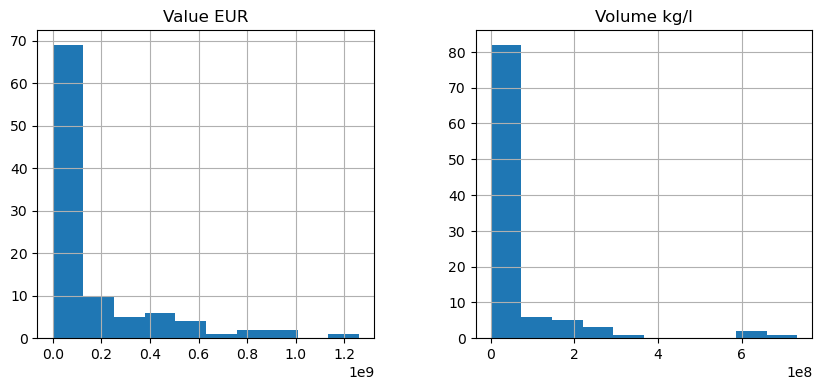

In [5]:
df[['Value EUR', 'Volume kg/l']].hist(figsize=(10, 4))

The histograms show that both sales value and sales volume are strongly right-skewed, with most observations concentrated at lower levels and only a small number of observations showing very large values. This indicates substantial variation across countries, years, and product categories. Since the dataset contains both value and volume information, the subsequent analysis examines whether higher sales volumes are associated with higher sales values, which would suggest a broadly positive value–volume relationship. Applying log transformation helps reduce the influence of extreme observations and makes the variables more suitable for regression analysis when testing this relationship.


array([[<Axes: title={'center': 'log_value'}>,
        <Axes: title={'center': 'log_volume'}>]], dtype=object)

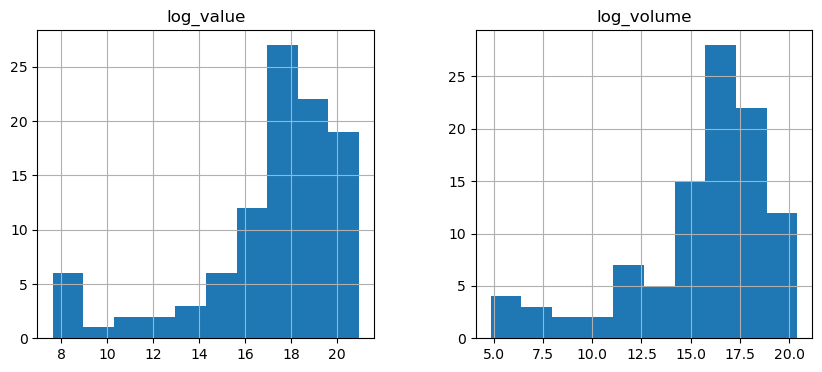

In [6]:
import numpy as np
df = add_sales_log_columns(df)
df[['log_value', 'log_volume']].hist(figsize=(10, 4))

After log transformation, the distributions of log_value and log_volume become less right-skewed compared with the original variables. The values are more spread out and less dominated by extreme observations, making them more suitable for correlation and OLS regression analysis.


In [7]:
import statsmodels.api as sm
X = sm.add_constant(df[['log_volume']])
model_log = fit_ols(df, ['log_volume'], 'log_value')
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:              log_value   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     2176.
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           1.01e-68
Time:                        20:52:14   Log-Likelihood:                -98.560
No. Observations:                 100   AIC:                             201.1
Df Residuals:                      98   BIC:                             206.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8911      0.290     13.424      0.0

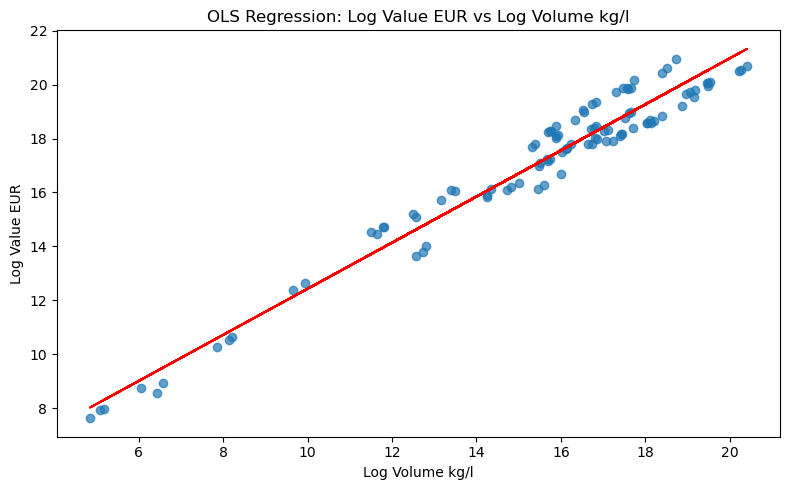

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['log_volume'], df['log_value'], alpha=0.7)
plt.plot(df['log_volume'], model_log.predict(X),color='red')
plt.title('OLS Regression: Log Value EUR vs Log Volume kg/l')
plt.xlabel('Log Volume kg/l')
plt.ylabel('Log Value EUR')
plt.tight_layout()
plt.show()

The log-log OLS regression shows a strong positive relationship between Volume kg/l and Value EUR. The model has a high R-squared value of 0.957, indicating that log volume explains most of the variation in log sales value. The coefficient of log_volume is positive and statistically significant, suggesting that higher sales volume is strongly associated with higher sales value. Therefore, since value and volume are highly correlated, the following analysis focuses on Value EUR as the main indicator and does not discuss Volume kg/l separately.


In [9]:
df_wide_value = create_wide_value_table(df)
df_wide_value.head()

,Country,Year,Other plant-based foods / snacks & spreads,Plant-based cheese,Plant-based ice cream,Plant-based meat/fish alternatives & ready meals,Plant-based milk & drinks,Plant-based yogurt,Total Value EUR
0,Austria,2018.0,NaN,NaN,NaN,47756571.0,60439596.8,28291439.0,136487606.8
1,Austria,2019.0,NaN,NaN,NaN,53453292.6,70771713.8,30617819.8,154842826.2
2,Austria,2020.0,NaN,NaN,NaN,86449040.1,95499407.6,40249951.8,222198399.5
3,Belgium,2018.0,NaN,NaN,NaN,82826628.6,116339917.4,43862862.0,243029408.0
4,Belgium,2019.0,NaN,NaN,NaN,87256217.5,116808606.3,46100561.0,250165384.8


In [10]:
country_descriptive = df_wide_value.groupby(['Country'])[['Total Value EUR']].describe()
country_descriptive

Total Value EUR                                            \
                         count          mean           std           min   
Country                                                                    
Austria                    3.0  1.711763e+08  4.512949e+07  1.364876e+08   
Belgium                    3.0  2.599085e+08  2.332998e+07  2.430294e+08   
Denmark                    3.0  8.203163e+07  1.129062e+07  6.907380e+07   
France                     3.0  7.610923e+08  8.409217e+07  6.713733e+08   
Italy                      3.0  1.116265e+09  2.726988e+07  1.089518e+09   
Netherlands                3.0  6.583211e+08  1.444540e+08  5.350270e+08   
Romania                    3.0  2.283707e+07  5.585797e+06  1.858581e+07   
Spain                      3.0  1.029092e+09  1.821256e+08  8.491867e+08   
United Kingdom             3.0  1.334718e+09  3.848071e+08  1.000049e+09   

                                                                        
                         25%           50%           75%           max  
Country                                                                 
Austria         1.456652e+08  1.548428e+08  1.885206e+08  2.221984e+08  
Belgium         2.465974e+08  2.501654e+08  2.683481e+08  2.865308e+08  
Denmark         7.816988e+07  8.726596e+07  8.851055e+07  8.975514e+07  
France          7.225817e+08  7.737901e+08  8.059518e+08  8.381134e+08  
Italy           1.102383e+09  1.115248e+09  1.129639e+09  1.144029e+09  
Netherlands     5.788511e+08  6.226752e+08  7.199681e+08  8.172609e+08  
Romania         1.967389e+07  2.076197e+07  2.496271e+07  2.916344e+07  
Spain           9.369578e+08  1.024729e+09  1.119044e+09  1.213359e+09  
United Kingdom  1.124487e+09  1.248924e+09  1.502053e+09  1.755181e+09

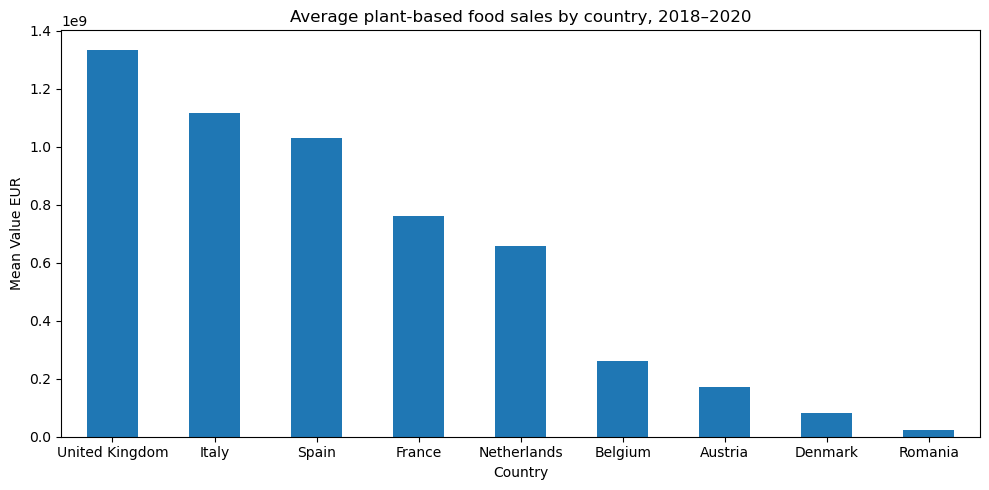

In [11]:
mean_value = country_descriptive[('Total Value EUR', 'mean')].sort_values(ascending=False)
mean_value.plot(kind='bar', figsize=(10, 5))
plt.title('Average plant-based food sales by country, 2018–2020')
plt.xlabel('Country')
plt.ylabel('Mean Value EUR')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The figure shows a clear concentration of plant-based food sales in a small number of markets from 2018 to 2020. The United Kingdom, Italy, and Spain accounted for the highest average sales values, suggesting that these countries had relatively larger and more developed plant-based food markets during this period. By contrast, countries such as Denmark and Romania showed much smaller sales values, indicating that market size differed substantially across Europe. This pattern suggests that plant-based food market development was uneven, with growth opportunities likely depending on country-specific market scale and consumer demand.


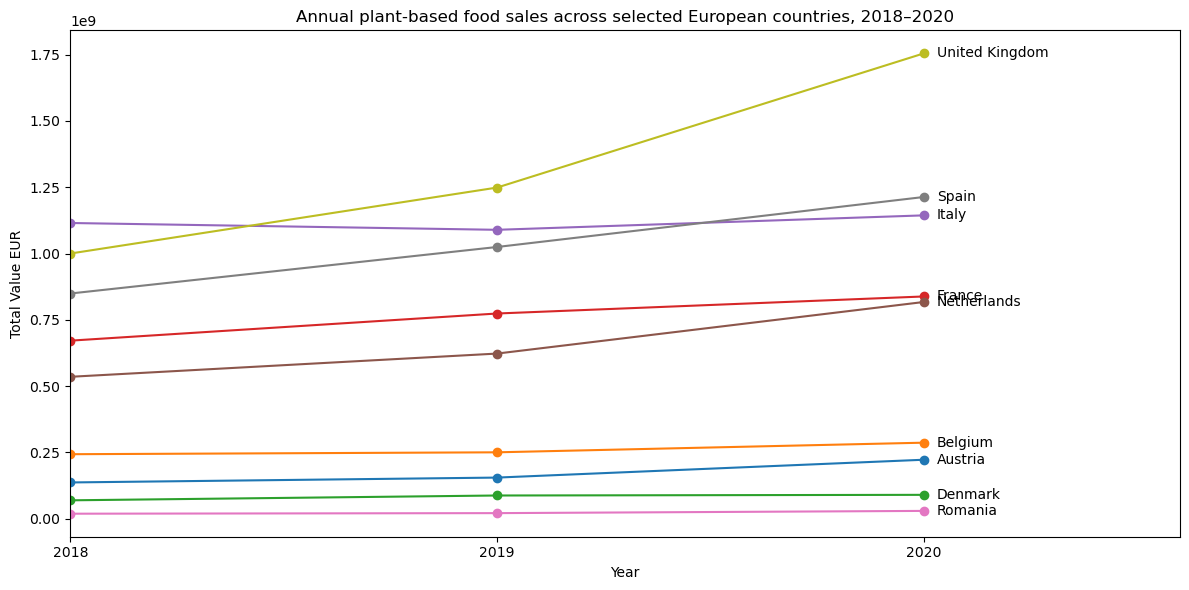

In [12]:
df_wide_value_wide = df_wide_value.pivot(
    index='Year',
    columns='Country',
    values='Total Value EUR')
ax = df_wide_value_wide.plot(
    figsize=(12, 6),
    marker='o',
    legend=False)
for country in df_wide_value_wide.columns:
    last_year = df_wide_value_wide.index[-1]
    last_value = df_wide_value_wide[country].iloc[-1]
    ax.text(last_year + 0.03, last_value, country, va='center')

plt.title('Annual plant-based food sales across selected European countries, 2018–2020')
plt.xlabel('Year')
plt.ylabel('Total Value EUR')
plt.xticks(df_wide_value_wide.index)
plt.xlim(df_wide_value_wide.index.min(), df_wide_value_wide.index.max() + 0.6)
plt.tight_layout()
plt.show()

Plant-based food sales increased in most selected European countries from 2018 to 2020, but the pace and scale of growth differed clearly across markets. The United Kingdom showed the strongest upward trend and became the leading market by 2020, while Spain and Italy remained consistently large markets. In contrast, countries such as Denmark and Romania stayed at much lower sales levels, suggesting that market expansion was uneven and mainly driven by a few major countries.


In [13]:
df_share, product_cols = create_share_table(df_wide_value)
df_share.head()

,Country,Year,Other plant-based foods / snacks & spreads,Plant-based cheese,Plant-based ice cream,Plant-based meat/fish alternatives & ready meals,Plant-based milk & drinks,Plant-based yogurt,Total Value EUR
0,Austria,2018.0,NaN,NaN,NaN,34.989676,44.282113,20.728211,136487606.8
1,Austria,2019.0,NaN,NaN,NaN,34.521000,45.705517,19.773483,154842826.2
2,Austria,2020.0,NaN,NaN,NaN,38.906239,42.979341,18.114420,222198399.5
3,Belgium,2018.0,NaN,NaN,NaN,34.080908,47.870716,18.048376,243029408.0
4,Belgium,2019.0,NaN,NaN,NaN,34.879413,46.692554,18.428034,250165384.8


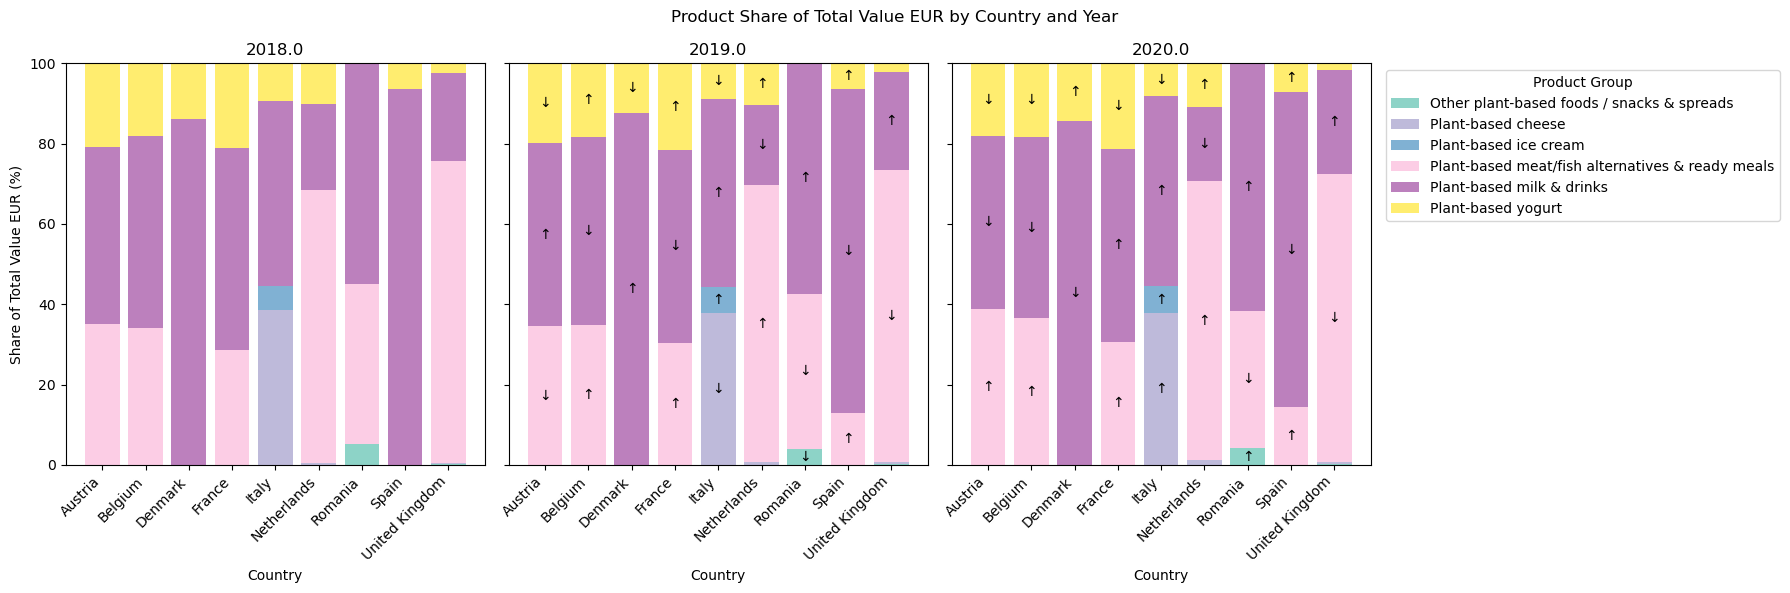

In [14]:
years = sorted(df_share['Year'].unique())
countries = sorted(df_share['Country'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(18, 6), sharey=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(product_cols)))
for i, year in enumerate(years):
    ax = axes[i]
    data = (df_share[df_share['Year'] == year].set_index('Country').reindex(countries)[product_cols].fillna(0))
    bottom = np.zeros(len(countries))
    for j, product in enumerate(product_cols):
        values = data[product].values
        ax.bar(countries,values,bottom=bottom,label=product,color=colors[j])
        if i > 0:
            prev_year = years[i - 1]
            prev_data = (df_share[df_share['Year'] == prev_year].set_index('Country').reindex(countries)[product_cols].fillna(0))
            change = data[product].values - prev_data[product].values
            for x, value, base, diff in zip(range(len(countries)), values, bottom, change):
                if value > 3:
                    if diff > 0:
                        ax.text(x, base + value / 2, '↑', ha='center', va='center')
                    elif diff < 0:
                        ax.text(x, base + value / 2, '↓', ha='center', va='center')
        bottom += values
    ax.set_title(str(year))
    ax.set_xlabel('Country')
    ax.set_xticks(range(len(countries)))
    ax.set_xticklabels(countries, rotation=45, ha='right')
    ax.set_ylim(0, 100)
axes[0].set_ylabel('Share of Total Value EUR (%)')

plt.suptitle('Product Share of Total Value EUR by Country and Year')
plt.legend(title='Product Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


The figure shows that the contribution of different product categories to total plant-based food sales varied substantially across countries and years. Plant-based milk and drinks accounted for a large share in many countries, especially in Denmark, Spain, Austria, Belgium, and France, indicating that this category was a key driver of total sales. In contrast, plant-based meat/fish alternatives and ready meals represented a particularly large share in the United Kingdom and the Netherlands, suggesting that these markets were more strongly shaped by meat-alternative products. The arrows show that category shares changed over time, but the overall market structure remained relatively stable in several countries. This suggests that plant-based food markets were not homogeneous across Europe; instead, each country appeared to have a different product-category profile, which may reflect differences in consumer preferences and market development pathways.


YouTube Video and Narrative Analysis

The following section uses the cleaned YouTube CSV produced after API extraction and title/description-based narrative coding. The extraction code is kept in `src`, while this notebook focuses on analysis. The CSV already contains one 0/1 column per narrative theme, such as `health`, `environment`, and `taste`; these direct theme columns replace the older positive/negative AI aspect-sentiment file.


In [15]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), Path.cwd().parent, Path("..").resolve()]
        if (path / "data").exists() and (path / "src").exists()
    ),
    Path("..").resolve(),
)
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from analysis_helpers import add_log_total_value, fit_ols, merge_narrative_sales
from youtube_analysis_helpers import (
    aggregate_youtube_narratives,
    create_ols_coefficient_table,
    format_label,
    parse_codebook_expressions,
    plot_ols_coefficients,
    plot_theme_expression_clouds,
    prepare_sales_country_year_value,
    prepare_youtube_video_data,
    read_youtube_csv,
    run_theme_only_ols_search,
    summarize_ols_choice,
    summarize_youtube_narratives,
    youtube_basic_descriptives,
    youtube_country_year_summary,
)

YOUTUBE_FILE = "ALL_11countries_2017_2020_aspect_sentiment_narrative_coded.csv"
CODEBOOK_FILE = "narrative_coding_codebook.csv"
narrative_cols = [
    "health",
    "environment",
    "taste",
    "animal_ethics",
    "recipe_cooking",
    "convenience_easy",
    "fitness_weight",
    "challenge_transition",
    "product_review_alternatives",
    "budget_shopping",
    "restaurant_travel",
]
ols_cols = [f"{col}_rate" for col in narrative_cols]


In [16]:
youtube_path = PROJECT_ROOT / "data/Clean" / YOUTUBE_FILE
df_youtube_raw = read_youtube_csv(youtube_path)
df_youtube = prepare_youtube_video_data(
    df_youtube_raw,
    narrative_cols,
    year_range=(2018, 2020),
)

print("Loaded YouTube CSV from:", youtube_path)
print("Raw rows:", len(df_youtube_raw))
print("Rows used for 2018-2020 analysis:", len(df_youtube))

display(youtube_basic_descriptives(df_youtube))

video_count_table = (
    youtube_country_year_summary(df_youtube)
    .pivot(index="Country", columns="Year", values="video_count")
    .fillna(0)
    .astype(int)
)
display(video_count_table)


Loaded YouTube CSV from: e:\东京大学\Video-Analysis--DataScience-Group\data\Clean\ALL_11countries_2017_2020_aspect_sentiment_narrative_coded.csv
Raw rows: 4150
Rows used for 2018-2020 analysis: 3192


,metric,value
0,videos,3192
1,countries,11
2,years,2018-2020
3,channels,1328
4,total_views,14331604820
5,median_views,336093.5
6,median_likes,9207.0
7,median_comments,445.0
8,median_duration_minutes,8.5


Year,2018,2019,2020
Country,,,
Austria,100,100,99
Belgium,99,99,100
Denmark,76,87,100
France,100,100,99
Germany,97,100,98
Italy,100,100,100
Netherlands,95,98,100
Poland,77,99,100
Romania,80,91,99


In [17]:
top_youtube_videos = (
    df_youtube
    .sort_values("view_count_numeric", ascending=False)
    [[
        "Country",
        "Year",
        "title",
        "channel_title",
        "view_count_numeric",
        "like_count_numeric",
        "comment_count_numeric",
        "url",
    ]]
    .head(10)
    .rename(
        columns={
            "view_count_numeric": "views",
            "like_count_numeric": "likes",
            "comment_count_numeric": "comments",
        }
    )
)

display(top_youtube_videos)


,Country,Year,title,channel_title,views,likes,comments,url
3451,Spain,2018,Yes Yes Vegetables Song | @CoComelon Nursery R...,Cocomelon - Nursery Rhymes,3.433949e+09,7139407.0,0.0,https://www.youtube.com/watch?v=ohHYABXMqUQ
3081,Romania,2018,Yes Yes Vegetables Song | @CoComelon Nursery R...,Cocomelon - Nursery Rhymes,3.433949e+09,7139407.0,0.0,https://www.youtube.com/watch?v=ohHYABXMqUQ
3082,Romania,2018,أنشودة الخضروات - vegetables song in arabic,Osratouna tv - قناة أسرتنا,7.830160e+08,1823159.0,0.0,https://www.youtube.com/watch?v=Pf1Y0JtfMPU
3161,Romania,2019,Bento e Totó - Viva a Vida Verde (Desenho Infa...,Bento e Totó,6.291023e+08,372482.0,0.0,https://www.youtube.com/watch?v=iJ7UinSD0XA
3551,Spain,2019,Bento e Totó - Viva a Vida Verde (Desenho Infa...,Bento e Totó,6.291023e+08,372482.0,0.0,https://www.youtube.com/watch?v=iJ7UinSD0XA
3162,Romania,2019,Hey Bear Sensory - Funky Veggies! - Fun Dance ...,Hey Bear Sensory,1.437990e+08,206083.0,0.0,https://www.youtube.com/watch?v=4cxGgnL7mSc
3552,Spain,2019,Aprenda los Vegetales para Niños con Blippi Es...,Blippi en Español,1.122566e+08,419825.0,0.0,https://www.youtube.com/watch?v=Rd4Fznng8qw
1998,Italy,2018,Vegas Jones - Malibu (prod. Boston George),VegasJonesVEVO,9.996905e+07,581125.0,12122.0,https://www.youtube.com/watch?v=5LrlmnBCvHw
3651,Spain,2020,Feeding Bill Gates a Fake Burger (to save the ...,Mark Rober,8.213737e+07,1748076.0,87821.0,https://www.youtube.com/watch?v=-k-V3ESHcfA
4051,United Kingdom,2020,Feeding Bill Gates a Fake Burger (to save the ...,Mark Rober,8.213737e+07,1748076.0,87821.0,https://www.youtube.com/watch?v=-k-V3ESHcfA


The descriptive tables keep the basic information from the YouTube video CSV: total rows, countries, years, channels, views, and video counts by country-year. The top-video table is useful because YouTube attention is highly unequal; a small number of videos can account for a large share of total views.


,narrative,label,mentioned_videos,mention_rate_pct,views_on_mentioned_videos,view_share_pct
4,recipe_cooking,Recipe Cooking,1680,52.631579,2657681333,18.544199
0,health,Health,1198,37.531328,1724338753,12.031721
2,taste,Taste,906,28.383459,1565167763,10.921092
5,convenience_easy,Convenience Easy,875,27.412281,1131165039,7.892801
8,product_review_alternatives,Product Review Alternatives,638,19.987469,700506273,4.887843
10,restaurant_travel,Restaurant Travel,319,9.993734,359826904,2.510723
9,budget_shopping,Budget Shopping,312,9.774436,408927323,2.853325
6,fitness_weight,Fitness Weight,277,8.677945,590336559,4.119124
7,challenge_transition,Challenge Transition,231,7.236842,542758194,3.787142
3,animal_ethics,Animal Ethics,186,5.827068,351996758,2.456088


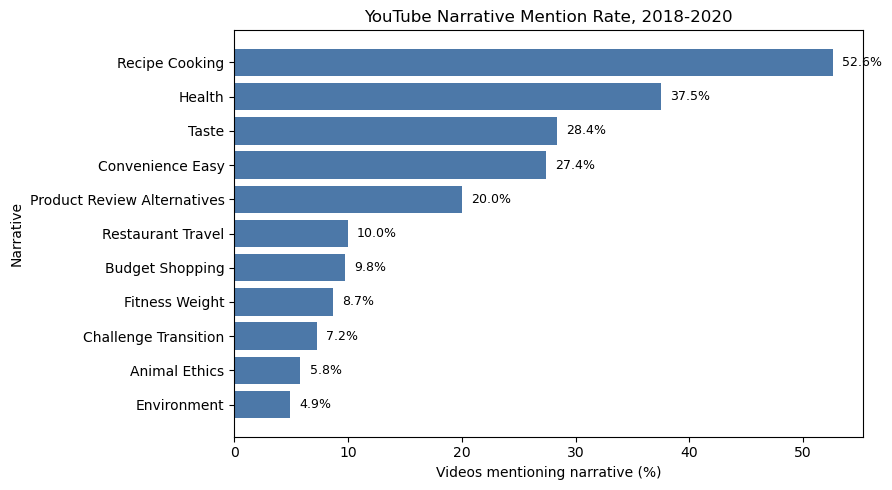

In [18]:
narrative_summary = summarize_youtube_narratives(df_youtube, narrative_cols)
display(narrative_summary)

plot_narratives = narrative_summary.sort_values("mention_rate_pct")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_narratives["label"], plot_narratives["mention_rate_pct"], color="#4C78A8")
ax.set_title("YouTube Narrative Mention Rate, 2018-2020")
ax.set_xlabel("Videos mentioning narrative (%)")
ax.set_ylabel("Narrative")
for y_pos, value in enumerate(plot_narratives["mention_rate_pct"]):
    ax.text(value + 0.8, y_pos, f"{value:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()


Narrative Coding Codebook

The codebook documents how often each theme appears and which title/description expressions most often triggered each code. The following text-size figures show one theme at a time, so labels do not overlap: larger words indicate expressions that appear in more videos, and the number on the right is the video count.


,theme,videos_flagged,share_of_valid_videos_pct,top_matched_expressions
0,Health,1556,37.49,health / healthy (820); nutrition / diet (655)...
1,Environment,230,5.54,environment / planet (97); zero waste (62); su...
2,Taste,1130,27.23,delicious / yummy (691); taste / flavor (501);...
3,Animal Ethics,232,5.59,animals (201); compassion / ethics (24); anima...
4,Recipe Cooking,2165,52.17,recipe (1623); meal / dish (778); cook / cooki...
5,Convenience Easy,1113,26.82,easy / simple (776); quick / fast (299); one p...
6,Fitness Weight,327,7.88,fitness / workout (159); weight loss / slimmin...
7,Challenge Transition,317,7.64,go vegan / become vegan (141); vegan for a day...
8,Product Review Alternatives,815,19.64,dairy substitute / alternative (306); tofu / t...
9,Budget Shopping,407,9.81,grocery / shopping (135); budget / cheap (122)...


,theme,theme_column,expression,mention_count_videos,rank_within_theme
0,Health,health,health / healthy,820,1
1,Health,health,nutrition / diet,655,2
2,Health,health,protein,230,3
3,Health,health,gluten free,206,4
4,Health,health,vitamins / supplements,150,5
5,Health,health,whole food plant based / WFPB,87,6
6,Health,health,oil free,63,7
7,Health,health,vitamin B12,63,8
8,Health,health,sugar free,50,9
9,Health,health,diabetes / heart disease,46,10


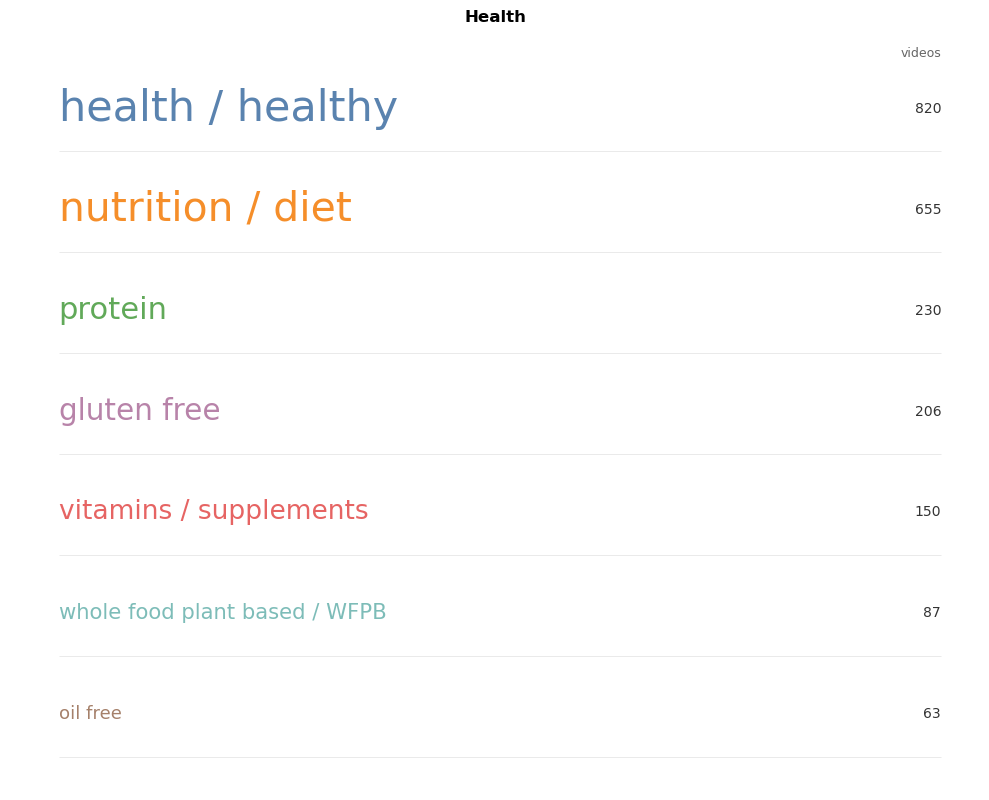

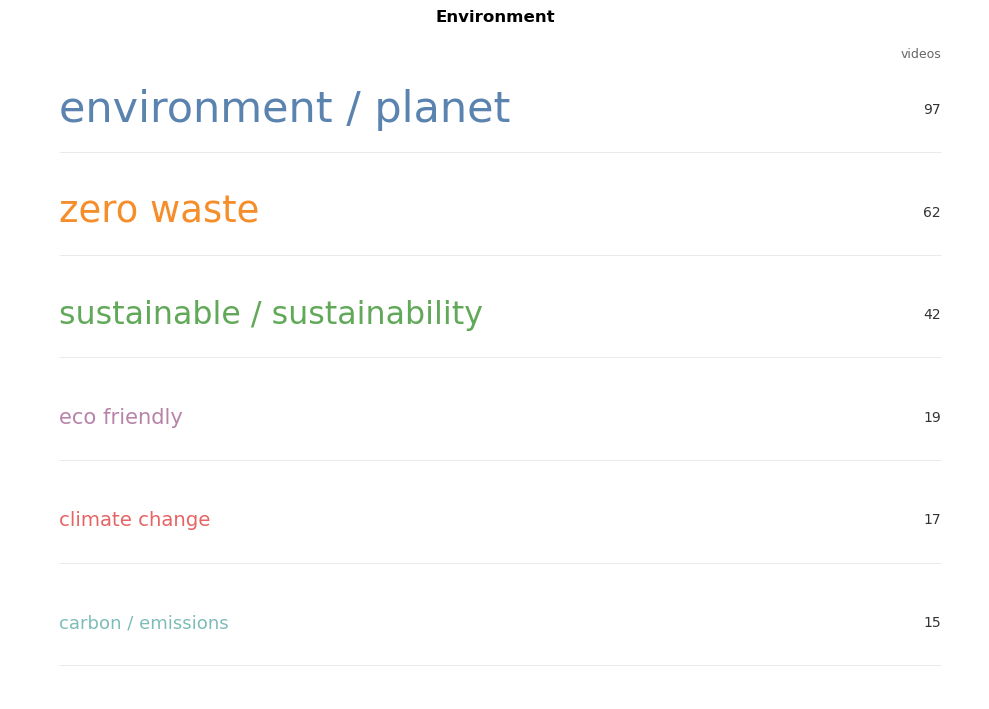

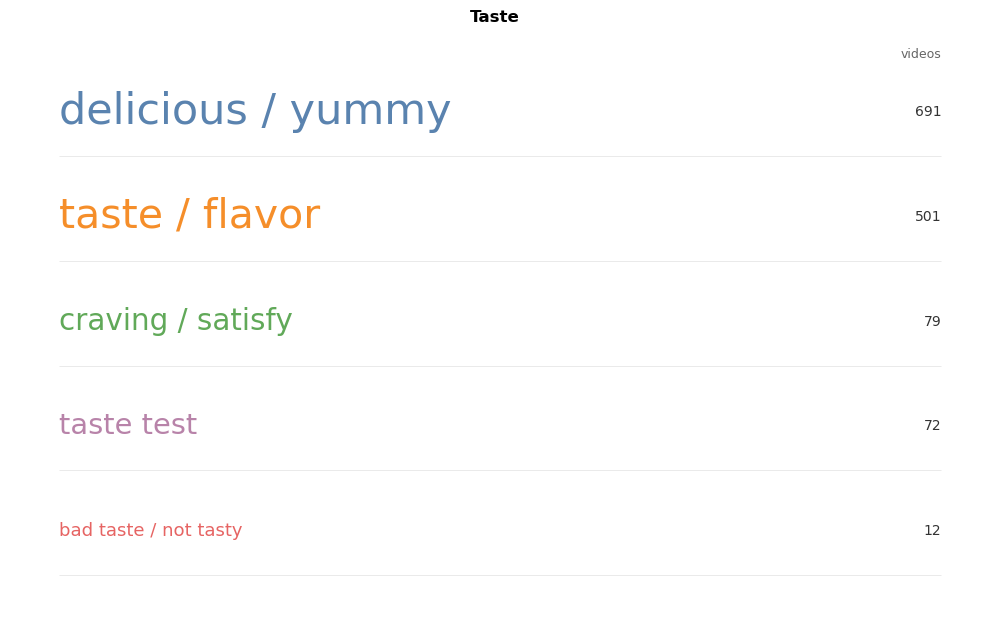

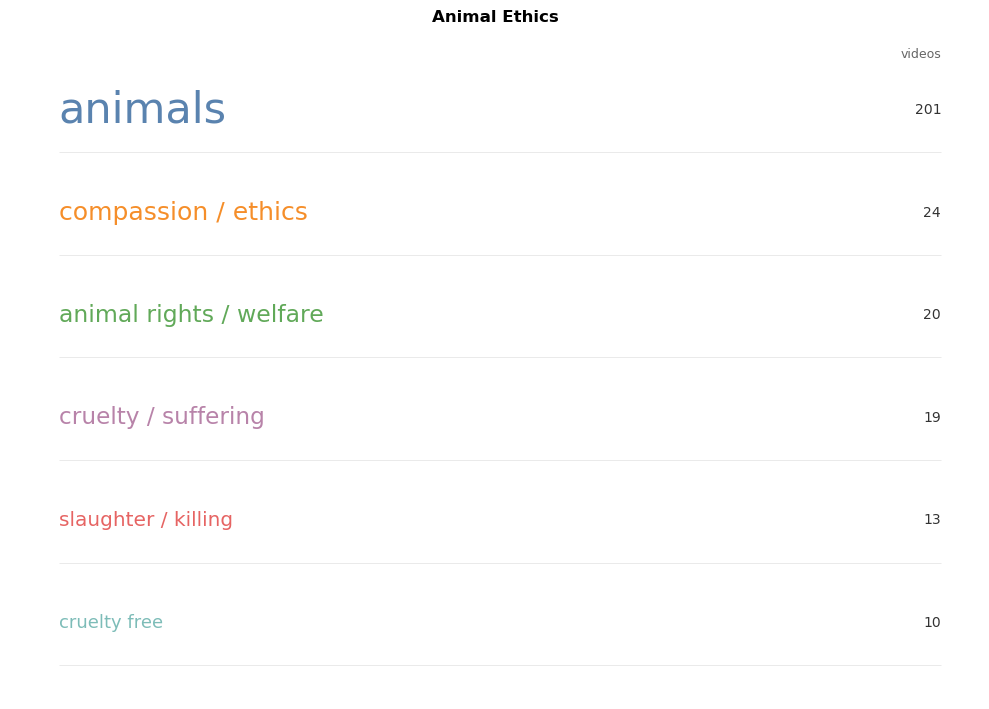

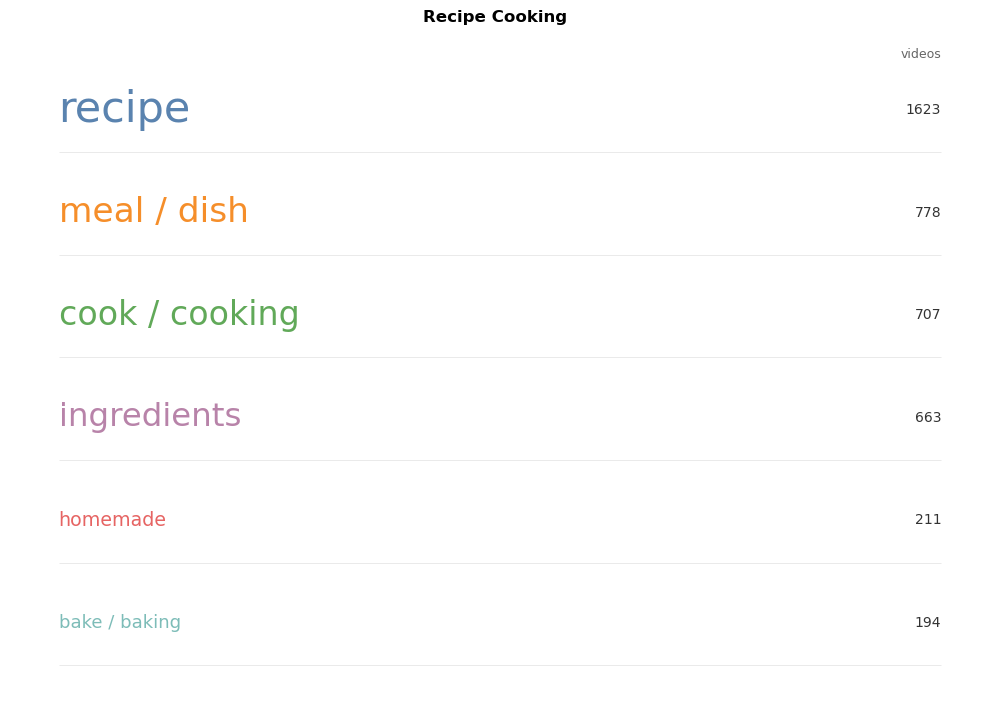

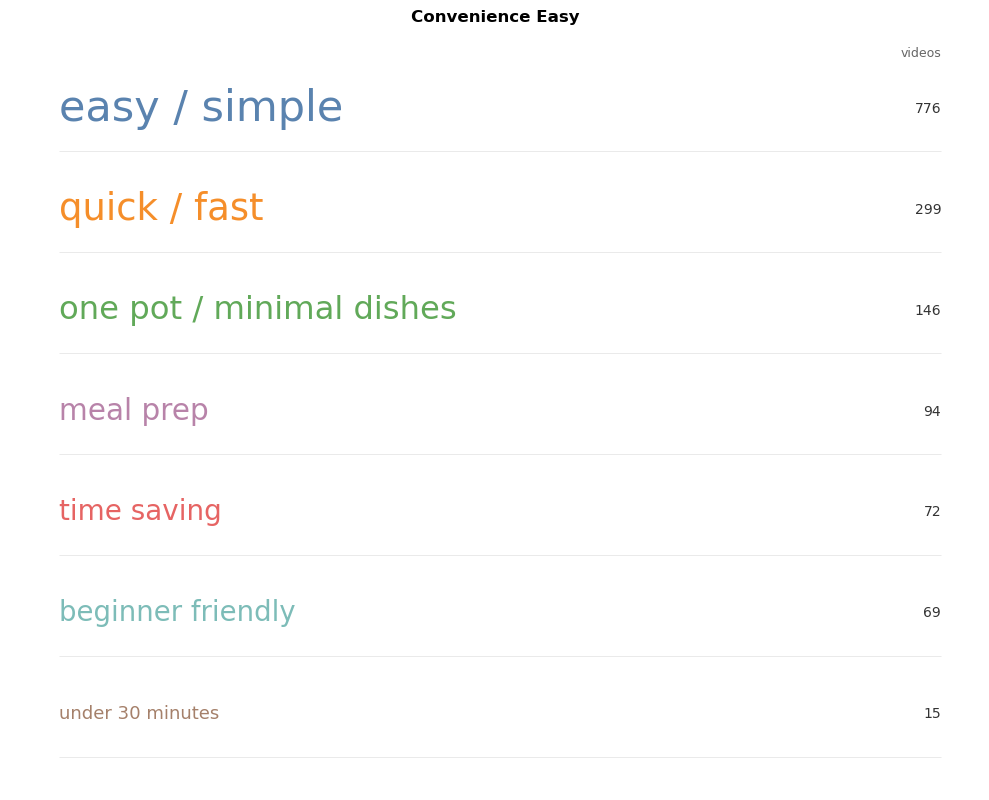

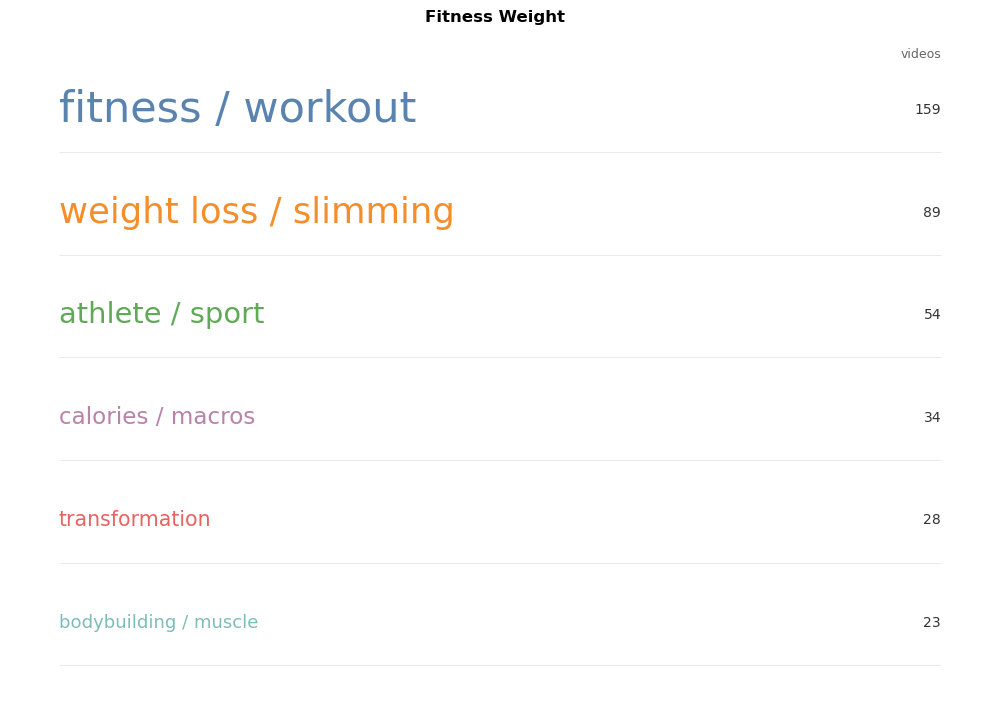

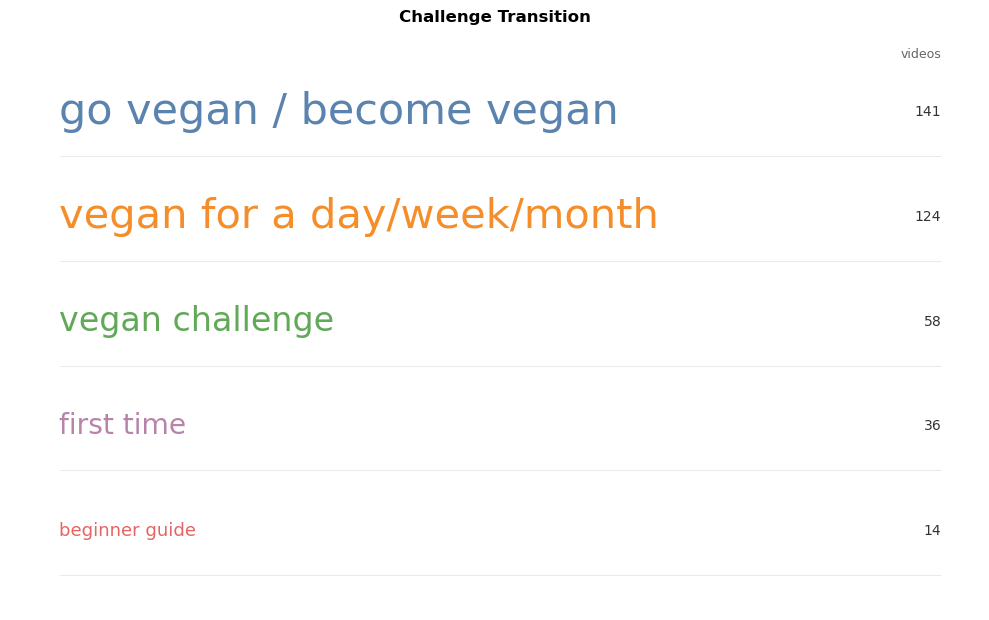

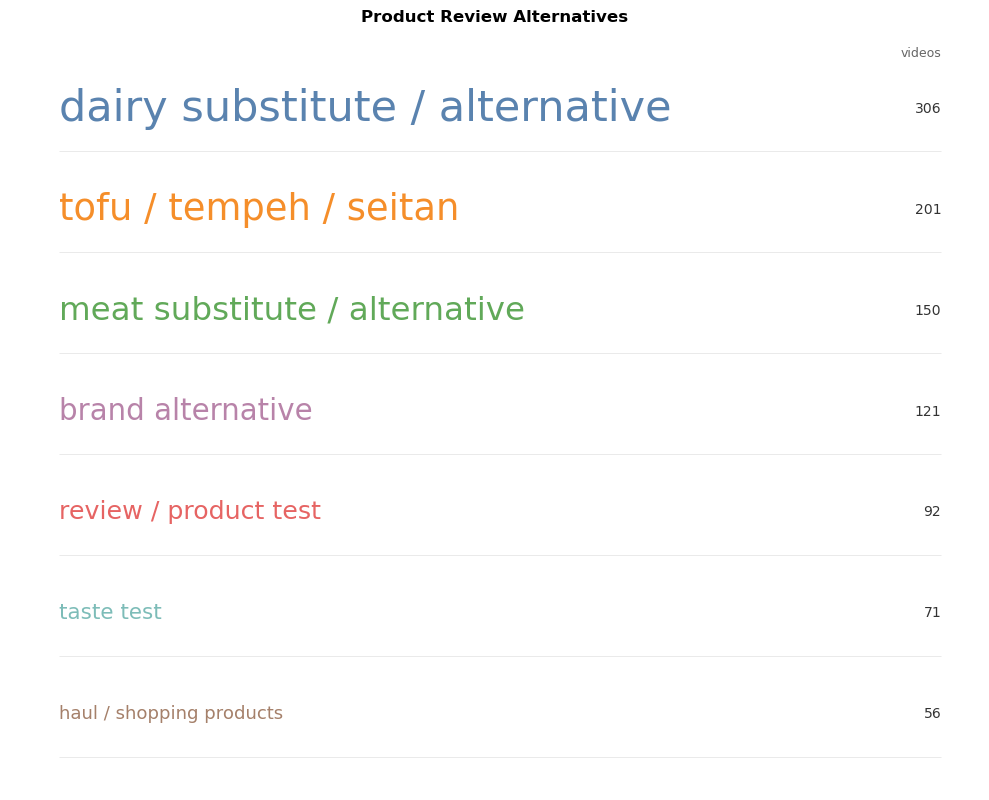

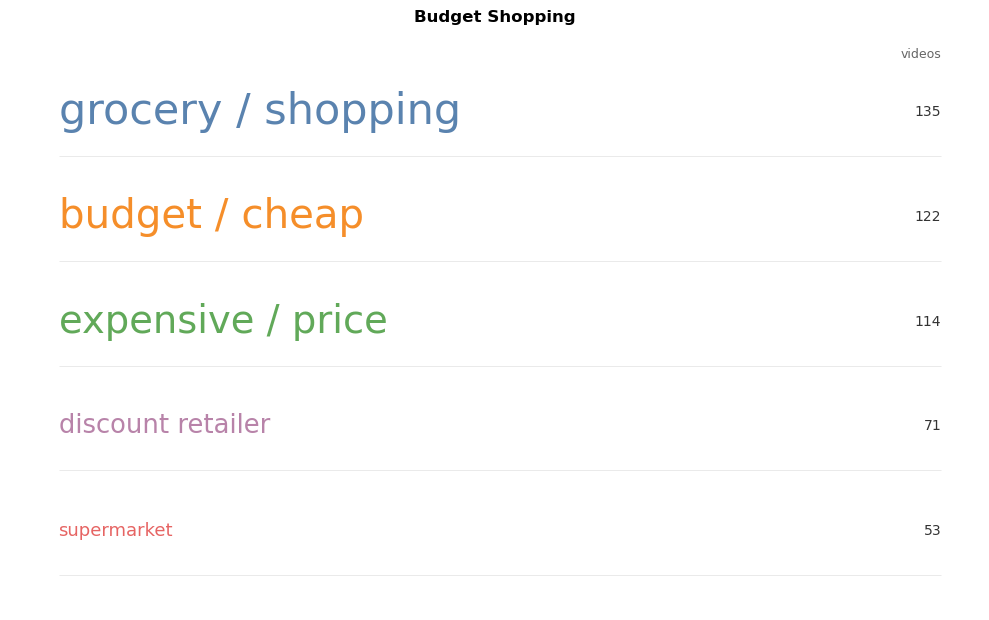

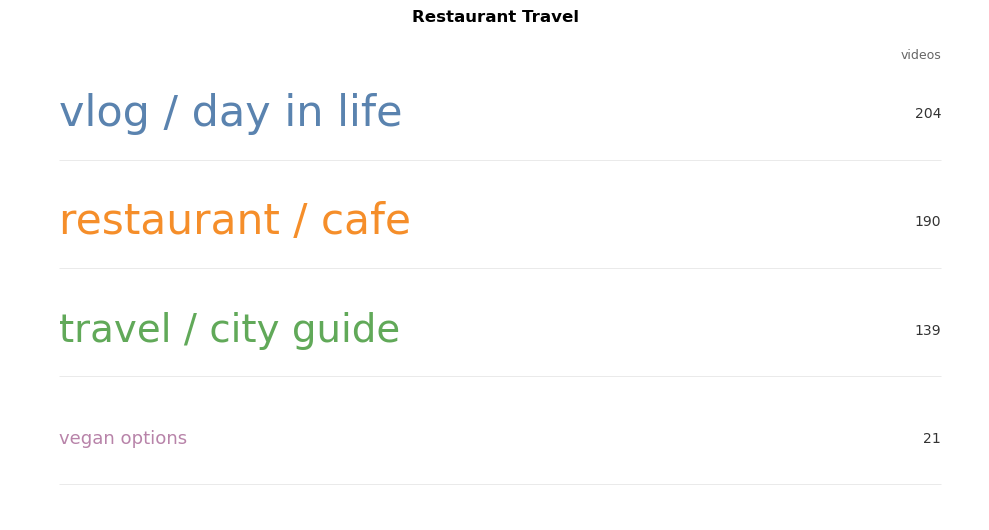

In [19]:
codebook_path = PROJECT_ROOT / "data/Clean" / CODEBOOK_FILE
narrative_codebook = pd.read_csv(codebook_path, encoding="utf-8-sig")

codebook_view = narrative_codebook.copy()
codebook_view["theme"] = codebook_view["theme_column"].apply(format_label)
codebook_view["share_of_valid_videos_pct"] = codebook_view["share_of_valid_videos"] * 100
display(codebook_view[[
    "theme",
    "videos_flagged",
    "share_of_valid_videos_pct",
    "top_matched_expressions",
]])

codebook_expressions = parse_codebook_expressions(narrative_codebook)
display(codebook_expressions.head(20))

plot_theme_expression_clouds(codebook_expressions, max_terms_per_theme=7)
plt.show()


,Health,Environment,Taste,Animal Ethics,Recipe Cooking,Convenience Easy,Fitness Weight,Challenge Transition,Product Review Alternatives,Budget Shopping,Restaurant Travel
Year,,,,,,,,,,,
2018,39.9,7.2,24.8,6.2,50.1,23.8,6.6,8.8,19.0,10.4,10.8
2019,35.8,4.3,29.5,4.2,52.0,26.8,9.3,5.5,20.1,9.2,11.0
2020,37.0,3.3,30.6,7.1,55.6,31.4,10.0,7.5,20.7,9.8,8.2


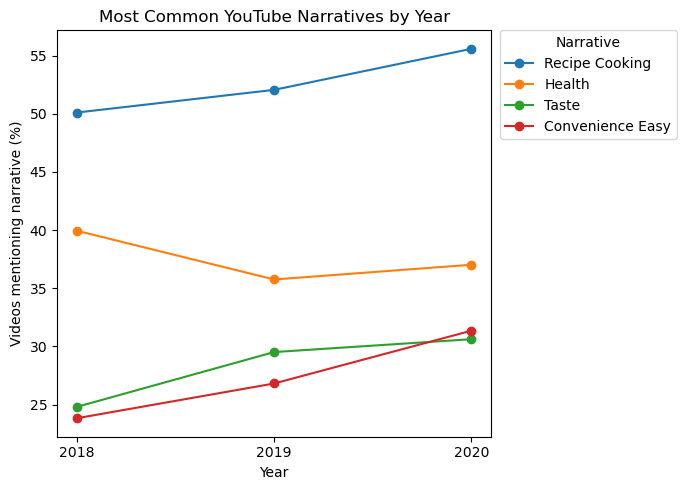

In [20]:
year_rates = aggregate_youtube_narratives(df_youtube, narrative_cols, ("Year",)).set_index("Year")
year_rate_table = year_rates[ols_cols].mul(100)
year_rate_table.columns = [format_label(col) for col in year_rate_table.columns]
display(year_rate_table.round(1))

top_narratives = narrative_summary.head(4)["narrative"].tolist()
top_year_cols = [format_label(f"{col}_rate") for col in top_narratives]
ax = year_rate_table[top_year_cols].plot(figsize=(9, 5), marker="o")
ax.set_title("Most Common YouTube Narratives by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Videos mentioning narrative (%)")
ax.set_xticks(year_rate_table.index)
ax.legend(title="Narrative", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()


The narrative summary now uses the new title/description-coded theme columns. Recipe/cooking, health, taste, convenience, product alternatives, budget/shopping, restaurant/travel, fitness/weight, challenge/transition, environment, and animal ethics are treated as direct mention flags. This makes the YouTube analysis more transparent because each 1/0 flag comes from explicit expressions found in the video title or description.


In [21]:
sales_country_year_for_merge = prepare_sales_country_year_value(
    pd.read_csv(PROJECT_ROOT / "data/Clean/plant_based_food_sales_data.csv")
)
narrative_country_year = aggregate_youtube_narratives(df_youtube, narrative_cols)
narrative_sales_country_year = merge_narrative_sales(narrative_country_year, sales_country_year_for_merge)
narrative_sales_country_year = add_log_total_value(narrative_sales_country_year)

missing_sales_country_year = (
    narrative_country_year[["Country", "Year"]]
    .merge(sales_country_year_for_merge[["Country", "Year"]], on=["Country", "Year"], how="left", indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

print("Country-year observations in YouTube data:", len(narrative_country_year))
print("Country-year observations used in sales relationship analysis:", len(narrative_sales_country_year))
print("Country-year observations without usable sales value:")
display(missing_sales_country_year)
display(narrative_sales_country_year.head())


Country-year observations in YouTube data: 33
Country-year observations used in sales relationship analysis: 30
Country-year observations without usable sales value:


,Country,Year
12,Germany,2018
13,Germany,2019
14,Germany,2020


,Country,Year,video_count,total_views,health_rate,environment_rate,taste_rate,animal_ethics_rate,recipe_cooking_rate,convenience_easy_rate,fitness_weight_rate,challenge_transition_rate,product_review_alternatives_rate,budget_shopping_rate,restaurant_travel_rate,Total Value EUR,log_total_value
0,Austria,2018,100,105188828.0,0.540000,0.200000,0.220000,0.120000,0.280000,0.160000,0.070000,0.150000,0.220000,0.070000,0.160000,136487606.8,18.731744
1,Austria,2019,100,71014996.0,0.480000,0.080000,0.250000,0.060000,0.420000,0.290000,0.120000,0.050000,0.240000,0.060000,0.140000,154842826.2,18.857921
2,Austria,2020,99,65273589.0,0.565657,0.050505,0.232323,0.080808,0.313131,0.202020,0.121212,0.060606,0.252525,0.111111,0.131313,222198399.5,19.219081
3,Belgium,2018,99,163803506.0,0.646465,0.090909,0.232323,0.121212,0.555556,0.262626,0.151515,0.131313,0.131313,0.050505,0.101010,243029408.0,19.308693
4,Belgium,2019,99,121394488.0,0.515152,0.020202,0.282828,0.030303,0.626263,0.303030,0.191919,0.080808,0.151515,0.090909,0.131313,250165384.8,19.337633


,narrative,label,corr_with_log_total_value
2,taste,Taste,0.471824
9,budget_shopping,Budget Shopping,0.400414
5,convenience_easy,Convenience Easy,0.399114
4,recipe_cooking,Recipe Cooking,0.355905
8,product_review_alternatives,Product Review Alternatives,0.330351
7,challenge_transition,Challenge Transition,0.220301
6,fitness_weight,Fitness Weight,0.088142
0,health,Health,0.062686
3,animal_ethics,Animal Ethics,0.059626
10,restaurant_travel,Restaurant Travel,0.024811


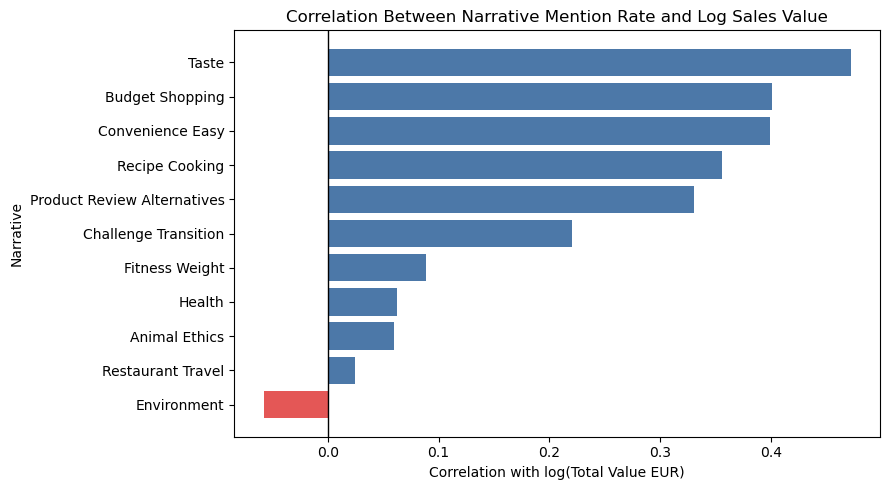

In [22]:
corr_table = pd.DataFrame({
    "narrative": narrative_cols,
    "label": [format_label(col) for col in narrative_cols],
    "corr_with_log_total_value": [
        narrative_sales_country_year[f"{col}_rate"].corr(narrative_sales_country_year["log_total_value"])
        for col in narrative_cols
    ],
}).sort_values("corr_with_log_total_value", ascending=False)

display(corr_table)

plot_corr = corr_table.sort_values("corr_with_log_total_value")
colors = ["#4C78A8" if value >= 0 else "#E45756" for value in plot_corr["corr_with_log_total_value"]]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_corr["label"], plot_corr["corr_with_log_total_value"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Correlation Between Narrative Mention Rate and Log Sales Value")
ax.set_xlabel("Correlation with log(Total Value EUR)")
ax.set_ylabel("Narrative")
plt.tight_layout()
plt.show()


The correlation chart is an exploratory first look, but it does not control for overlap between narratives. The OLS section below uses only the eleven coded narrative theme rates as candidate explanatory variables. It tests all possible non-empty combinations of those theme variables and keeps the highest adjusted R-squared model, which rewards fit while penalizing unnecessary extra predictors.


In [23]:
regression_data = narrative_sales_country_year[
    ["Country", "Year", "Total Value EUR", "log_total_value"] + ols_cols
].dropna().copy()

adjusted_ranked_models, adjusted_best_rate_cols, adjusted_best_ols_model = run_theme_only_ols_search(
    regression_data,
    ols_cols,
    fit_ols,
)

display(adjusted_ranked_models.drop(columns="rate_cols").head(20))
display(summarize_ols_choice(adjusted_best_ols_model, adjusted_best_rate_cols))

adjusted_best_ols_coefficients = create_ols_coefficient_table(
    adjusted_best_ols_model,
    adjusted_best_rate_cols,
    scale=0.10,
).rename(columns={
    "coefficient": "coefficient_per_10pp",
    "conf_low": "conf_low_per_10pp",
    "conf_high": "conf_high_per_10pp",
})
display(adjusted_best_ols_coefficients.sort_values("coefficient_per_10pp", ascending=False))

print("Highest adjusted R-squared theme-only OLS summary")
print(adjusted_best_ols_model.summary())


,n_predictors,themes,r_squared,adjusted_r_squared,aic,bic
0,3,"Taste, Challenge Transition, Budget Shopping",0.409980,0.341900,92.573258,98.178047
1,4,"Taste, Challenge Transition, Budget Shopping, ...",0.420511,0.327793,94.032959,101.038946
2,4,"Taste, Fitness Weight, Challenge Transition, B...",0.417107,0.323844,94.208680,101.214667
3,4,"Taste, Animal Ethics, Challenge Transition, Bu...",0.416710,0.323383,94.229102,101.235089
4,4,"Taste, Recipe Cooking, Challenge Transition, B...",0.414830,0.321203,94.325620,101.331607
5,4,"Taste, Convenience Easy, Challenge Transition,...",0.413762,0.319964,94.380343,101.386330
6,4,"Health, Taste, Challenge Transition, Budget Sh...",0.410915,0.316662,94.525653,101.531640
7,4,"Environment, Taste, Challenge Transition, Budg...",0.410111,0.315728,94.566594,101.572580
8,4,"Taste, Challenge Transition, Product Review Al...",0.410102,0.315718,94.567061,101.573048
9,5,"Taste, Challenge Transition, Product Review Al...",0.432596,0.314386,95.400715,103.807900


,model,selection_rule,n_observations,n_predictors,r_squared,adjusted_r_squared,f_pvalue,themes
0,Highest adjusted R-squared theme-only OLS,highest adjusted R-squared,30,3,0.40998,0.3419,0.002952,"Taste, Challenge Transition, Budget Shopping"


,variable,label,coefficient_per_10pp,p_value,conf_low_per_10pp,conf_high_per_10pp
2,budget_shopping_rate,Budget Shopping,1.759611,0.020444,0.294597,3.224624
1,challenge_transition_rate,Challenge Transition,1.163283,0.049842,0.000864,2.325703
0,taste_rate,Taste,0.951885,0.019959,0.162775,1.740996


Highest adjusted R-squared theme-only OLS summary
                            OLS Regression Results                            
Dep. Variable:        log_total_value   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     6.022
Date:                Sat, 27 Jun 2026   Prob (F-statistic):            0.00295
Time:                        20:52:21   Log-Likelihood:                -42.287
No. Observations:                  30   AIC:                             92.57
Df Residuals:                      26   BIC:                             98.18
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

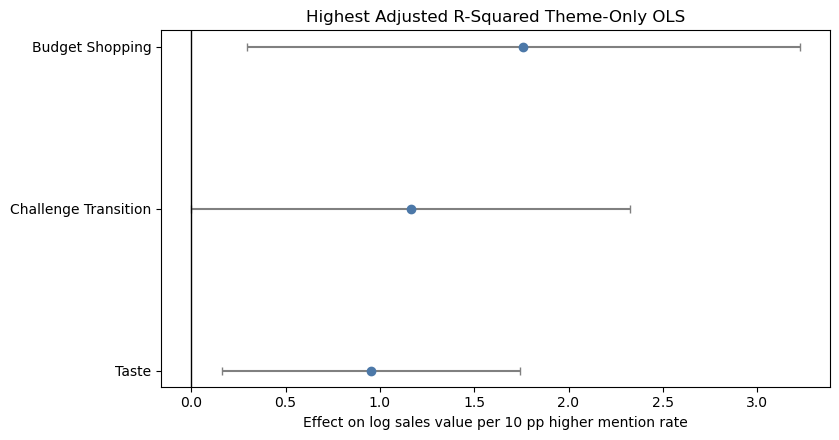

In [24]:
plot_ols_coefficients(
    adjusted_best_ols_coefficients,
    "Highest Adjusted R-Squared Theme-Only OLS",
    "#4C78A8",
)
plt.show()


The OLS model above is selected only from the eleven coded narrative themes. No grouped variables, attention controls, or other transformed explanatory variables are included. Adjusted R-squared is used as the selection rule because it balances model fit with parsimony. The result should still be read as exploratory model selection rather than causal evidence.
